In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/raw/german_credit_data.csv')
df.head(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


In [3]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nMissing values as percentage:")
print(df.isnull().sum() / len(df) * 100)

Shape: (1000, 11)

Column names: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

Data types:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Missing values as percentage:
Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit am

Target distribution:
Risk
good    700
bad     300
Name: count, dtype: int64

As percentages:
Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64


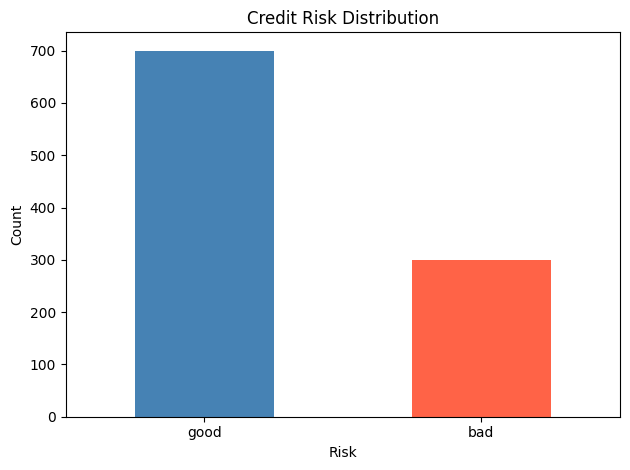

In [4]:
print("Target distribution:")
print(df['Risk'].value_counts())
print("\nAs percentages:")
print(df['Risk'].value_counts(normalize=True) * 100)

df['Risk'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'tomato'],
    title='Credit Risk Distribution'
)
plt.xlabel('Risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

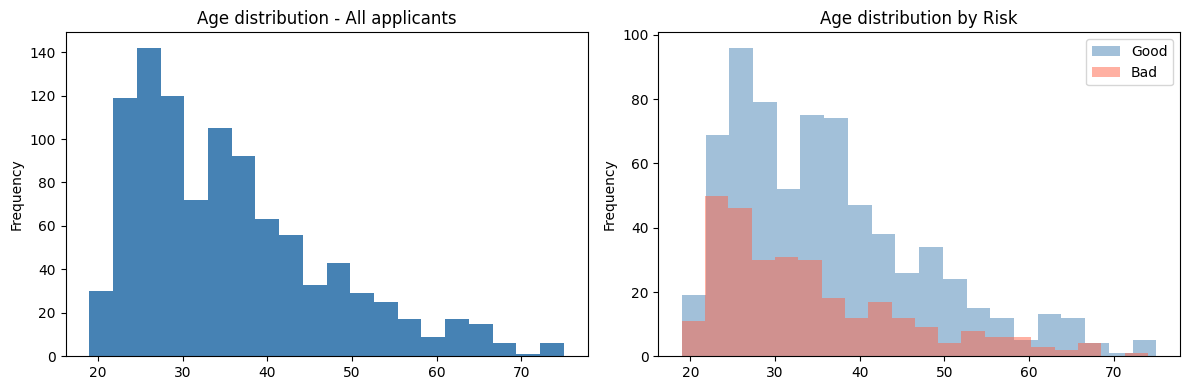

Average age - Good risk: 36.2
Average age - Bad risk:  34.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Age'].plot(
    kind='hist',
    bins=20,
    ax=axes[0],
    title='Age distribution - All applicants',
    color='steelblue'
)

df[df['Risk']=='good']['Age'].plot(
    kind='hist',
    bins=20,
    ax=axes[1],
    title='Age distribution by Risk',
    color='steelblue',
    alpha=0.5,
    label='Good'
)

df[df['Risk']=='bad']['Age'].plot(
    kind='hist',
    bins=20,
    ax=axes[1],
    color='tomato',
    alpha=0.5,
    label='Bad'
)

axes[1].legend()
plt.tight_layout()
plt.show()

print("Average age - Good risk:", df[df['Risk']=='good']['Age'].mean().round(1))
print("Average age - Bad risk: ", df[df['Risk']=='bad']['Age'].mean().round(1))

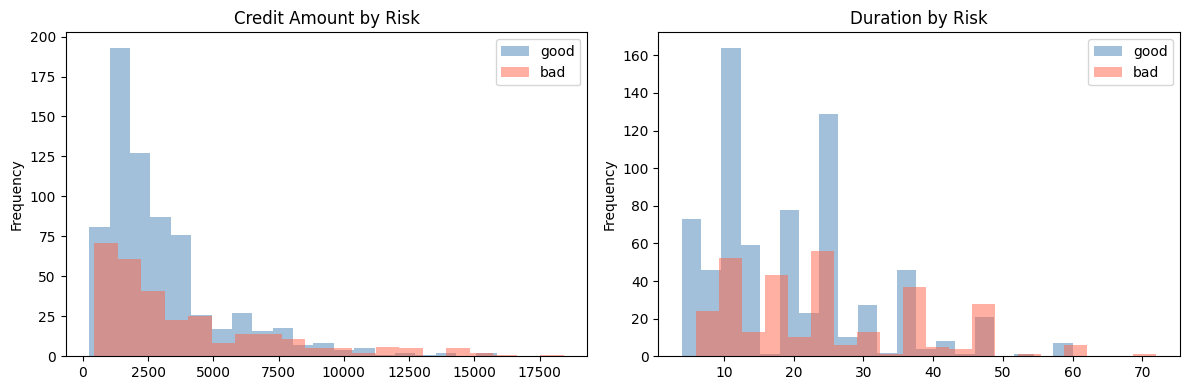

Average credit amount - Good: 2985.0
Average credit amount - Bad:  3938.0

Average duration - Good: 19.2
Average duration - Bad:  24.9


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for risk, color in [('good', 'steelblue'), ('bad', 'tomato')]:
    df[df['Risk']==risk]['Credit amount'].plot(
        kind='hist',
        bins=20,
        ax=axes[0],
        alpha=0.5,
        color=color,
        label=risk
    )
    df[df['Risk']==risk]['Duration'].plot(
        kind='hist',
        bins=20,
        ax=axes[1],
        alpha=0.5,
        color=color,
        label=risk
    )

axes[0].set_title('Credit Amount by Risk')
axes[0].legend()
axes[1].set_title('Duration by Risk')
axes[1].legend()
plt.tight_layout()
plt.show()

print("Average credit amount - Good:", df[df['Risk']=='good']['Credit amount'].mean().round(0))
print("Average credit amount - Bad: ", df[df['Risk']=='bad']['Credit amount'].mean().round(0))
print("\nAverage duration - Good:", df[df['Risk']=='good']['Duration'].mean().round(1))
print("Average duration - Bad: ", df[df['Risk']=='bad']['Duration'].mean().round(1))

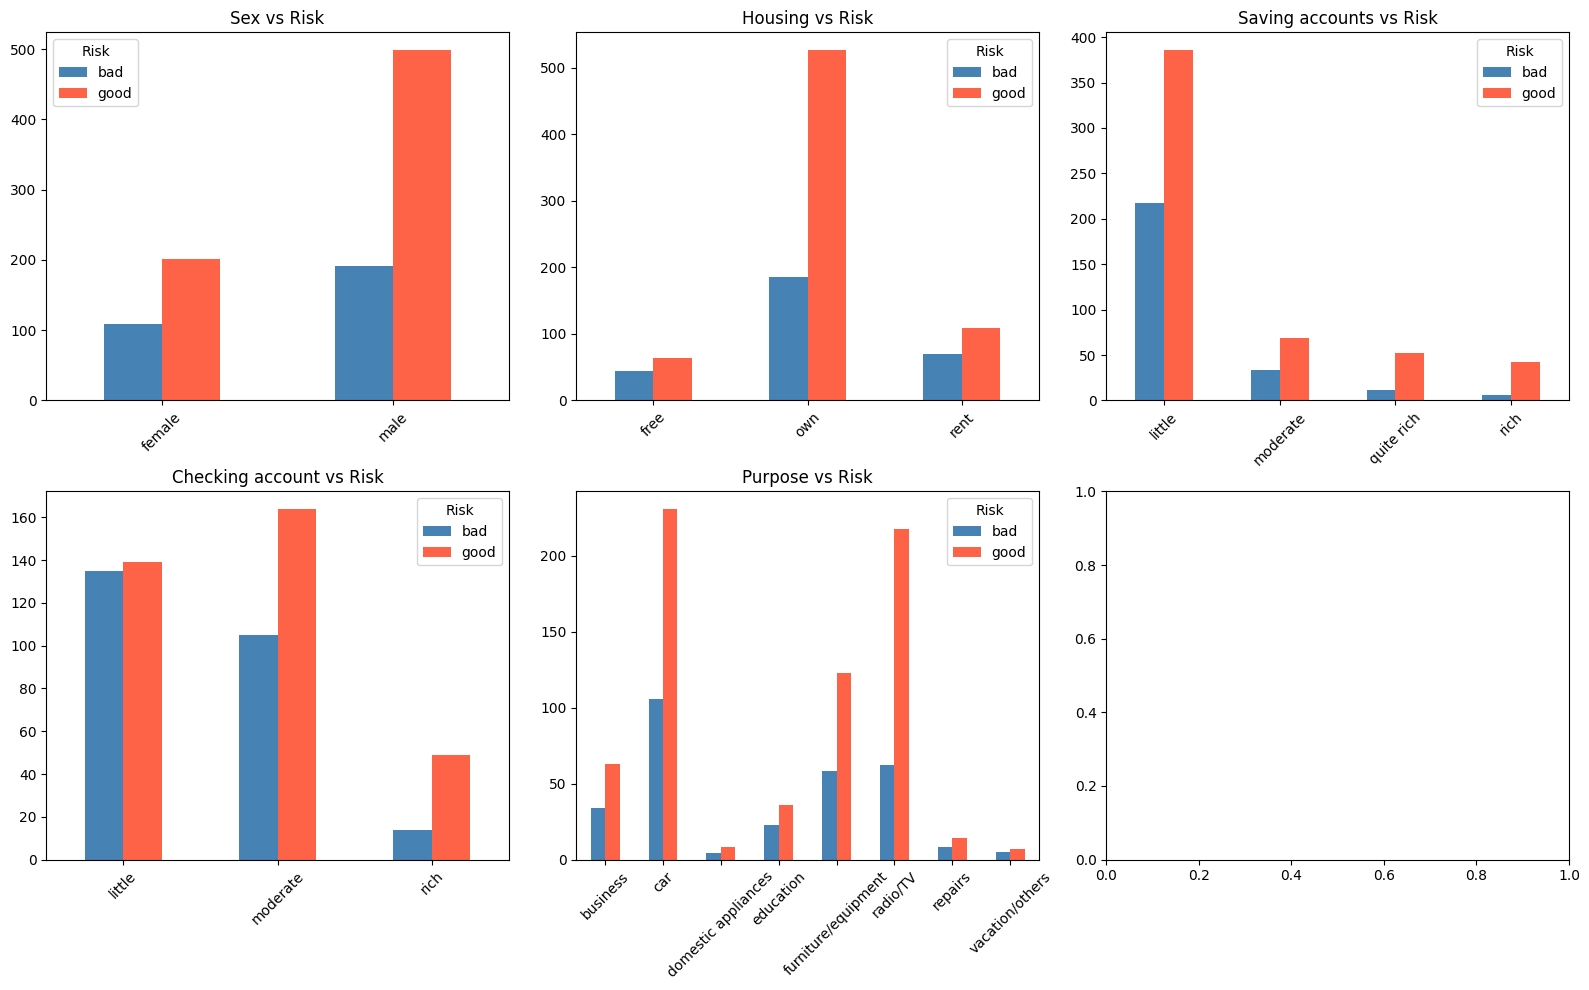

In [9]:
cat_columns = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(cat_columns):
    df.groupby([col, 'Risk']).size().unstack().plot(
        kind='bar',
        ax=axes[idx],
        color=['steelblue', 'tomato'],
        title=f'{col} vs Risk'
    )
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
print("Missing values:")
print(df.isnull().sum())
print("\nMissing as percentage:")
print((df.isnull().sum() / len(df) * 100).round(1))

print("\nDefault rate when Saving accounts is missing:")
print(df[df['Saving accounts'].isnull()]['Risk'].value_counts(normalize=True) * 100)

print("\nDefault rate when Checking account is missing:")
print(df[df['Checking account'].isnull()]['Risk'].value_counts(normalize=True) * 100)

Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Missing as percentage:
Unnamed: 0           0.0
Age                  0.0
Sex                  0.0
Job                  0.0
Housing              0.0
Saving accounts     18.3
Checking account    39.4
Credit amount        0.0
Duration             0.0
Purpose              0.0
Risk                 0.0
dtype: float64

Default rate when Saving accounts is missing:
Risk
good    82.513661
bad     17.486339
Name: proportion, dtype: float64

Default rate when Checking account is missing:
Risk
good    88.324873
bad     11.675127
Name: proportion, dtype: float64


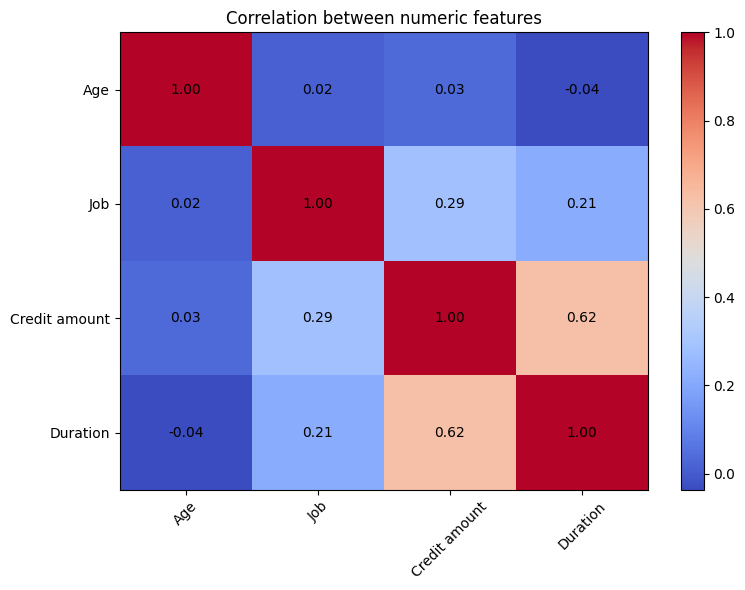

In [12]:
numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration']

df_corr = df[numeric_cols].copy()
correlation = df_corr.corr()

plt.figure(figsize=(8, 6))
plt.title('Correlation between numeric features')

im = plt.imshow(correlation, cmap='coolwarm', aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{correlation.iloc[i, j]:.2f}',
                ha='center', va='center')

plt.tight_layout()
plt.show()

In [ ]:
## EDA Summary — What we found and what we'll do about it

### Finding 1: Useless column
`Unnamed: 0` is just a row number with no information.
Action: Drop it completely.

### Finding 2: Class imbalance
70% good risk, 30% bad risk.
Action: Use class_weight='balanced' during training.
Consider SMOTE from imbalanced-learn if needed.

### Finding 3: Missing values
Saving accounts: 183 missing (18.3%)
Checking account: 394 missing (39.4%)
Action: Fill missing values with 'unknown' category.
Also create binary indicator columns — saving_missing
and checking_missing — to capture the missingness signal.

### Finding 4: Text columns need encoding
Sex, Housing, Saving accounts, Checking account, Purpose
are all text. Models need numbers.
Action: Use Label Encoding or One Hot Encoding
during preprocessing.

### Finding 5: Age signal
Older applicants tend to have better credit risk.
Action: Keep Age as a feature — it's informative.

### Finding 6: Credit amount and Duration signal
Higher credit amounts and longer durations correlate
with higher default risk.
Action: Keep both as features.

### Finding 7: Categorical signal
Different categories have different default rates.
Savings level, checking account level, and purpose
of loan are all informative.
Action: Encode these carefully — ordinal encoding
for savings and checking since they have a natural
order (little < moderate < quite rich < rich).
One hot encoding for purpose and housing since
they have no natural order.